# Summaries

## Lesson 9A Summary (Previous)

Jonathan walks you through the Stable Diffusion Deep Dive notebook, peeling apart the high-level pipeline into its individual components so you can see — and modify — exactly what happens when an image is generated. The code is adapted directly from the `__call__` method of the default Hugging Face Stable Diffusion pipeline, now laid bare in a notebook you can run alongside.

The first component is the **variational autoencoder (VAE)**. Stable Diffusion is a *latent* diffusion model: it never touches pixels directly. Instead, a pre-trained VAE compresses a 512×512 image down to a 4×64×64 latent representation — a factor-of-8 reduction per spatial dimension, roughly 64× less data — yet the decoded reconstruction is nearly indistinguishable from the original. This is what makes high-resolution generation tractable: the diffusion model only ever works with these compact 64×64 latents. The input dimensions need not be 512; any multiple of 8 will do, and the same factor-of-8 reduction applies.

Next comes **noise and the scheduler**. During training, noise is added to latents at varying amounts controlled by a schedule (parameterized by `beta_start`, `beta_end`, and `beta_schedule`). At sampling time we use far fewer steps — say 15 instead of 1000 — mapped to a subset of training timesteps. The `sigmas` attribute shows the actual noise level at each sampling step, starting high and tapering to zero. The `add_noise` function is deceptively simple: `noisy_samples = original_samples + noise × σ`. The **image-to-image pipeline** exploits this directly: encode an input image, noise it to some intermediate timestep, then denoise from there with a new prompt. The "strength" parameter simply controls which step you start from — how much of the schedule you skip — giving you control over how much of the original composition survives.

The **text encoding process** is dissected layer by layer. A prompt is tokenized into exactly 77 tokens (padded or truncated), then each token is looked up in a learned embedding table (~50,000 entries, each 768-dimensional). These token embeddings are position-independent, so a separate learned positional embedding (one per position out of 77) is added element-wise. The combined embeddings are then fed through a stack of Transformer encoder blocks — attention, feed-forward, normalization, skip connections — producing the final encoder hidden states (output embeddings) that condition the UNet. Breaking this into steps enables powerful manipulation: you can swap a token embedding to change the subject, average two token embeddings (e.g. "puppy" and "skunk") to create chimeras, or blend final output embeddings from two entirely different prompts.

**Textual inversion** is the main practical application of token-level manipulation. A small learned embedding file (`embeds.bin`) — just a single 768-dimensional vector — captures a new concept or style. Jonathan demonstrates "birb style," trained on watercolor bird paintings, producing a charming mouse-in-an-apron in that style simply by inserting the learned embedding at the right position in the token sequence. Over 1,400 community-contributed concepts exist in the Stable Diffusion Concepts Library, and training your own is straightforward.

The **UNet and classifier-free guidance (CFG)** section reveals what the diffusion model actually predicts. The UNet takes noisy latents, the current timestep, and text embeddings, and outputs a noise prediction of the same shape as the latents. The predicted denoised image is computed as x̂₀ = xₜ − σ·ε_θ. Progress visualizations show the predicted output starting blurry and gradually sharpening, while the latents themselves change only incrementally per step. CFG works by running *two* copies through the model — one conditioned on the prompt, one unconditional (empty prompt) — and combining predictions: ε_final = ε_uncond + s·(ε_cond − ε_uncond). The guidance scale *s* controls how aggressively the model follows the prompt; higher values produce more prompt-faithful but potentially less natural results.

Jonathan then steps away from the notebook for a **paper-and-pen explanation of sampling**. He introduces the space of all possible images, manifold theory (real images occupy a lower-dimensional surface within that vast space), and the score function (predicting how to get back to the manifold from a noisy point). Single-step denoising fails because from a random starting point the model can only predict a blurry average. The solution is iterative ODE solving: remove a little noise, get a better prediction, repeat. **First-order solvers** (Euler's method) use simple linear steps. **Second-order solvers** account for curvature by estimating how the prediction changes, enabling larger steps at the cost of multiple model evaluations per step. **Linear multi-step (LMS) sampling** is a practical hybrid — it keeps a buffer of past predictions to approximate curvature without extra model calls. Finally, Jonathan presents an alternative framing: **sampling as optimization**, where the predicted noise amount serves as a loss and standard optimizer tricks (adaptive learning rates, momentum) drive the latents toward a plausible image. Not yet mainstream, but a thought-provoking perspective.

The lesson concludes with **loss-based guidance**. Beyond text and image-to-image control, you can define an arbitrary loss function on the predicted denoised output (decoded to image space) and use its gradient to nudge the latents. A simple "make it blue" loss demonstrates the principle: every few iterations, decode the predicted output, compute the loss, trace gradients back to the latents, and subtract ∇(loss)·σ². The result is a distinctly blue campfire painting. Caveats: decoding and gradient tracing are expensive (hence applying every 5th step), and the shortcut of not tracing through the UNet itself trades accuracy for memory. For more precise gradients, full backprop through decoder and UNet is possible with gradient checkpointing. The technique generalizes to color palettes, CLIP-based text guidance, classifier-based steering, and more.

---

- **Lesson Challenges**
  - Experiment with different noise timesteps to see how the noised image changes at different stages
  - Try different schedulers from the diffusers library
  - Explore mixing embeddings from different prompts at different blend factors
  - Tweak the `blue_loss_scale` to see how guidance strength affects the output
  - Try applying the loss every iteration instead of every 5th, with a lower scale

- **Potential Research Directions**
  - Sampling as optimization: applying modern optimizer techniques (Adam, momentum, weight decay) to the denoising loop
  - Dynamic step-count estimation during sampling
  - More efficient gradient-based guidance via gradient checkpointing through the full UNet
  - Combining textual inversion with loss-based guidance for fine-grained style + content control
  - Exploring what information each of the four latent channels encodes

- **Homework**
  - Run through the notebook yourself, modifying prompts, guidance scales, and sampling steps
  - Train your own textual inversion concept using the linked community notebooks
  - Implement a custom loss function (e.g. CLIP-based or style-transfer-based) for guided generation

- **Things Jeremy Says You Should Do**
  - *(This lesson is presented by Jonathan; no explicit Jeremy recommendations are given in this segment.)*

- **Resources**
  - [Stable Diffusion Deep Dive Notebook](https://github.com/fastai/diffusion-nbs/blob/master/Stable%20Diffusion%20Deep%20Dive.ipynb) — the notebook walked through in this lesson
  - [Hugging Face Diffusers Library](https://github.com/huggingface/diffusers) — pipelines, schedulers, and models used throughout
  - [Stable Diffusion Concepts Library](https://huggingface.co/sd-concepts-library) — 1,400+ community-contributed textual inversion embeddings
  - [Textual Inversion training notebook](https://colab.research.google.com/github/huggingface/notebooks/blob/main/diffusers/sd_textual_inversion_training.ipynb) — for training your own learned embeddings
  - [AI Coffee Break: GLIDE video](https://www.youtube.com/watch?v=lvv4N2nf-HU) — recommended explanation of classifier-free guidance
  - [Score-based generative modeling (Yang Song's blog)](https://yang-song.net/blog/2021/score/) — background on the SDE/ODE framing of diffusion


## Lesson 9B Summary (Current)

Waseem, an Entrepreneur in Residence at fast.ai currently visiting headquarters in Australia, walks through the math behind diffusion models together with Tanishq, a PhD student at UC Davis who also works at Stability AI. Jeremy is present throughout, interjecting with connections to earlier course material. Waseem has no formal math background and approaches this as someone who found the derivation beautiful and wants to help others parse the notation and concepts.

The talk opens with the very first piece of math from the 2015 Sohl-Dickstein et al. paper: q(x⁰), the data distribution. The notation is unpacked carefully — x is the input variable, the superscript 0 implies a sequence (x¹, x², …), and q is a probability density function. The choice of q rather than p hints that p will appear later for the thing we actually want to model, with q playing the supporting role.

Tanishq grounds q(x⁰) concretely: if we're working with images, x⁰ is just an image — say an MNIST digit. q acts as a "magic API" (the same metaphor from Lesson 9) that takes in an image and returns its probability of looking like a real digit. You can't write down what q actually is, but you imagine it exists. PDFs rarely appear in code directly, yet they let you treat random quantities as ordinary functions with centuries of math behind them, and they eventually reduce to simple equations.

The forward transition q(x^t | x^{t-1}) is introduced next — a conditional PDF describing how one image becomes a slightly noisier version. It's defined as a Gaussian: N(x^t; √(1−β_t) x^{t-1}, β_t I). The semicolon separates the variable from the parameters (mean and covariance). The normal distribution is chosen because it's described by just two parameters (mean and covariance) and has thin tails, so behavior outside a small region can be ignored.

Jeremy explains the covariance matrix by connecting it to CLIP from an earlier lesson: if you take the dot product of the same set of vectors against themselves, the diagonal gives you variance and the off-diagonal entries tell you how pairs of pixels co-vary. Setting all off-diagonal entries to zero assumes pixels are independent — unrealistic for real images, but the assumption we make here. The identity matrix I has ones on the diagonal and zeros elsewhere; multiplying by β_t gives each pixel variance β_t with no cross-pixel relationships.

The formula's behavior at the extremes is then examined. When β = 0, the mean is exactly the previous image and the variance is zero — you get the same image back. When β = 1, the mean is zero and the variance is I — pure noise. Between these extremes, you get a mixture of signal and noise, controlled by β.

Chaining many such small steps produces the forward diffusion process: a sequence from a clean image to pure noise. This is formally a Markov process with Gaussian transitions — "Markov" meaning each step depends only on the previous one, "Gaussian" meaning the transitions are normal distributions. Sampling is straightforward: draw from N(0, 1), multiply by the standard deviation, add the mean.

The crucial insight, discovered around the 1950s, is that the reverse process — going from noise back toward data — has the same functional form: p(x^{t-1} | x^t) = N(x^{t-1}; □, △), where □ and △ are unknown parameters to learn. q describes the forward process, p describes the reverse. The question becomes: how do we find those unknowns?

The answer involves the likelihood function, but computing it exactly requires intractable high-dimensional integrals over thousands of steps. Taking the log helps — the log is monotonically increasing (so the optimum doesn't change), converts products to sums, and cancels out the exponentials in Gaussians. Even the log likelihood can't be optimized directly, but there exists a tractable surrogate called the ELBO (Evidence Lower Bound). Optimizing the ELBO is almost as good as optimizing the true likelihood, and because everything is Gaussian, the KL Divergence between forward and reverse distributions can be computed analytically.

The 2020 DDPM paper (Denoising Diffusion Probabilistic Model) simplifies further with two assumptions: the reverse variance is a fixed constant (not learned), and the forward step sizes are also constants. This reduces the entire problem to predicting the noise — train a neural network that takes a noisy image and predicts what part is noise, using plain MSE loss. Despite these simplifications, DDPM produces much better images.

Tanishq then connects this to the score function perspective from Lesson 9. The score function is the gradient of the log likelihood, ∇_x log p(x). Theorems from the 1950s show that for Gaussian noise, denoising is equivalent to learning the score function. So the probabilistic framework (predict noise via ELBO) and the score-based framework (learn the gradient of the log likelihood) arrive at the same place — predicting noise *is* learning the score function. This unifies two bodies of literature spanning decades.

The talk closes with Waseem reflecting on the beauty of these cross-field mathematical connections, and Jeremy reassuring viewers that understanding all this math is not required — the course will cover what's needed gradually over many lessons.

---

- **Lesson Challenges** — None explicitly stated.

- **Potential Research Directions**
  - The original 2015 Sohl-Dickstein et al. paper and how its approach differs from modern implementations
  - The 1950s results on reversibility of Markov processes with Gaussian transitions
  - Connections between the probabilistic (DDPM/ELBO) and score-based (score matching) perspectives
  - Learning the variance in the reverse process (relaxing the DDPM constant-variance assumption)
  - Non-Gaussian transition kernels and whether the same framework extends

- **Homework** — None explicitly assigned.

- **Things Jeremy Says You Should Do**
  - You don't need to understand all the math in this video — it will be covered gradually across the course
  - Check out the main course lesson (Lesson 9)
  - Watch Johno's video for a deeper dive into code and concepts

- **Resources**
  - [Sohl-Dickstein et al. 2015 — "Deep Unsupervised Learning using Nonequilibrium Thermodynamics"](https://arxiv.org/abs/1503.03585)
  - [Ho et al. 2020 — "Denoising Diffusion Probabilistic Models" (DDPM)](https://arxiv.org/abs/2006.11239)
  - Lesson 9 of fast.ai Part 2 (the "magic API" and score function approach)
  - Johno's video (referenced but not linked)


## Lesson 10 Summary (Next)

The lesson opens with a showcase of student work from the past week. @puru demonstrates spherical linear interpolation (slerp) between two latent noise starting points, producing smooth transitions — first between otter images, then morphing an old car into a modern Ferrari. @namrata extends this idea by interpolating from a dinosaur to a bird, yielding a striking intermediate "dino-bird." John Richmond earns "dad of the week" by turning his daughter's dog into a unicorn using img2img at varying strength values — too low and the dog barely changes, too high and the dog vanishes entirely, but at 0.3 he finds the sweet spot. Maureen applies different artist style prompts to Johno's parrot image, discovering that a Frida Kahlo prompt produces Frida Kahlo herself (because she appears in virtually all her own paintings), while the Jackson Pollock version retains a ghostly parrot shape. Jeremy reminds everyone to watch Johno's Stable Diffusion walkthrough videos and the Wasim–Tanishq video on the math of diffusion, quoting a student named Alex who assumed the math video would be incomprehensible but found it entirely accessible. Jason Antic, creator of DeOldify, has joined the research team and, within a single week, generated high-quality face images from scratch on a single GPU in just a few hours using classic deep learning optimizers rather than differential equation solvers — a research direction Jeremy considers extremely promising.

A quick recap of Lesson 9 follows, now presented as polished slides converted from hand-drawn OneNote notes. The core idea is restated: take a digit (say a seven), add noise, feed the noisy image to a U-Net that predicts the noise, compare that prediction to actual noise via a loss function, and update the U-Net's weights. An embedding of the digit label can be passed in as conditioning so the model later generates specific digits on demand. The VAE/latents piece is glossed over as a computational shortcut — compressing images into a smaller latent space. For richer prompts beyond single digits, CLIP provides the bridge: an image encoder and a text encoder are trained so that matching image–text pairs produce similar feature vectors, using contrastive loss (the "CL" in CLIP). At inference time, we feed a text embedding plus random noise into the U-Net, which predicts noise to subtract. We subtract only a little, then repeat — progressively denoising across many steps. The lesson shows intermediate results at steps 0, 6, 12, 18, 24, 30, 36, 42, where a face gradually emerges from static. The noisy images look strange (not like Gaussian noise) because they are decoded VAE latents.

Jeremy then introduces three recent papers. The first, "Progressive Distillation for Fast Sampling of Diffusion Models," uses a teacher–student distillation scheme. The fully trained Stable Diffusion model (teacher) runs two denoising steps; a student model learns to jump directly from the input to the two-step result. That student then becomes the new teacher, and a fresh student learns to match two of the previous student's steps — effectively doubling the step size each round (1 → 2 → 4 → 8), collapsing what originally took hundreds of steps down to just a handful. The second paper, "On Distillation of Guided Diffusion Models," extends this to classifier-free guided diffusion (CFGD). Normally CFGD requires running the U-Net twice per step (once with the prompt, once with an empty prompt) and combining the outputs via a guidance scale. This paper folds guidance into the distillation process: the student receives noise, prompt, and guidance scale as inputs, and learns to replicate the teacher's guided output across a range of guidance values — reducing 60 steps down to as few as 4. Jeremy encourages watching Johno's paper walkthrough video and notes that the actual algorithms, once you look past the math, are mostly primary-school arithmetic turned into a few lines of code. The third paper, "Imagic: Text-Based Real Image Editing with Diffusion Models," released just hours before the lesson, demonstrates editing real photographs via text prompts — making a bird spread its wings, a dog sit down, a person give a thumbs up — while preserving identity and context. The method has three steps: (A) optimize the text embedding to make the diffusion model reconstruct the input image, (B) fine-tune the entire model to output the exact input image given that optimized embedding, and (C) interpolate between the original target embedding and the optimized embedding, then pass it through the fine-tuned model. Jeremy emphasizes the societal implications: anyone can now generate believable photos of events that never occurred.

The lesson then dives into the Stable Diffusion pipeline code, built from scratch using the individual Hugging Face components. The text encoder (CLIP's `clip-vit-large-patch-14`), VAE (`CompVis/stable-diffusion-v1-4`), and U-Net are loaded via `from_pretrained`. A scheduler (Katherine Crowson's LMS discrete scheduler) maps time steps to noise levels. The full inference loop is walked through step by step: tokenize the prompt (padding to fixed length — GPUs prefer uniform-sized batches), encode via CLIP to get a 77×768 embedding tensor, do the same for the empty string and concatenate both (a trick so the GPU processes guided and unguided predictions simultaneously). Random latents are created at shape 1×4×H/8×W/8 (the factor-of-8 compression comes from the VAE), scaled by the scheduler's initial noise sigma. The denoising loop iterates over 70 time steps (jumping from 999 down by ~14 each time — Jeremy stresses that "time step" is a terrible name since these are really just noise-level indices, not even integers). Inside the loop: concatenate the two latent copies, scale, run through the U-Net, chunk the output into unconditional and text predictions, apply the guidance scale formula, and call `scheduler.step` to update latents. After the loop, the VAE decoder converts latents back to pixel space (dividing by 0.18215, a magic number from the paper), values are clamped from [-1,1] to [0,1], reordered for PIL, and converted to a displayable image. Jeremy then consolidates everything into two compact cells and introduces single-letter variable names (g for guidance scale, u for unconditional prediction, t for text prediction) to make the code look as close to the paper's equations as possible. He generates "a photograph of an astronaut riding a horse" and "an oil painting of an astronaut riding a horse in the style of Grant Wood." The code is further refactored into three small functions that fit on one screen.

The second half of the lesson marks a major pivot: building everything from the foundations toward Stable Diffusion. The foundations are defined as Python, the Python standard library, matplotlib, and Jupyter/nbdev — nothing else. Once a feature is reimplemented from scratch, the real library version is then permitted. The plan is to create smaller but architecturally identical versions of the VAE, U-Net, and CLIP encoder, collectively forming a library called "mini-ai." Jeremy works with MNIST — 50,000 handwritten digit images, 28×28 pixels, loaded via gzip and pickle, unpacked using destructuring assignment.

He pauses to advocate strongly for reading the Python documentation, demonstrating Jupyter's Shift+Tab for inspecting signatures, `?` for docs, and `??` for source code, plus keyboard shortcuts like Ctrl+Shift+Hyphen to split cells and Alt+Enter to create new ones. The flat 784-element pixel list is reshaped into 28×28 using a custom `chunks` generator function — a two-line function using `yield`, which Jeremy explains as one of Python's most underused features. He demonstrates `itertools.islice`, the two-argument form of `iter()` (callable plus sentinel), and the general power of iterators for streaming data without loading everything into memory.

To enable two-dimensional indexing (`image[20, 15]` instead of `image[20][15]`), Jeremy builds a minimal `Matrix` class with `__init__` and `__getitem__` dunder methods — just enough to justify graduating to PyTorch tensors, which provide the same indexing plus vastly more. The `map` function converts all data to tensors in one line. He explains `reshape` (including the `-1` shorthand), then takes a historical detour into APL — the array-oriented language created by Ken Iverson in the late 1950s, inspired by tensor analysis. APL called them "arrays," NumPy inherited that name, and PyTorch inexplicably switched to "tensors" — but they are all the same thing: rectangular blocks of numbers. Rank is just the number of dimensions. Jeremy mentions the fast.ai forums' APL study section with 17 sessions covering the entire language.

The lesson's final deep dive is into random number generation from scratch. True randomness requires physical sources: the ANU quantum vacuum generator, Cloudflare's wall of lava lamps, or Intel's RDRAND instruction — all too slow for deep learning workloads. Instead, pseudo-random number generators (PRNGs) use deterministic math that produces sequences appearing random. Jeremy implements the Wichmann–Hill algorithm (Python's PRNG before version 2.3), showing how `seed()` initializes global state as a tuple of three integers, and each call to `rand()` transforms and replaces that state. The output passes both visual tests: a scatter plot shows no obvious correlation between successive values, and a histogram shows uniform distribution.

Then comes a critical practical warning. When `os.fork()` creates a child process, both parent and child inherit identical copies of the random state — and therefore produce identical "random" numbers. Jeremy demonstrates this bug live: his custom `rand()`, PyTorch's `torch.rand()`, and NumPy's `np.random.rand()` all fail after a fork, producing matching values in parent and child. Only Python's built-in `random.random()` correctly reinitializes. This matters enormously in deep learning, where data loaders commonly fork worker processes for parallel augmentation. fastai itself once had this exact bug. Jeremy benchmarks his custom PRNG against PyTorch's: 3ms vs 73µs for generating 7,840 numbers — so from here on, the real PyTorch version is used. The lesson concludes by creating a 784×10 tensor of random numbers — the weight matrix for a linear classifier mapping 28×28 pixel inputs to 10 digit classes.

---

**Lesson Challenges**

- Implement negative prompts in the from-scratch Stable Diffusion pipeline
- Implement image-to-image generation in the from-scratch pipeline
- Add a callback system to the from-scratch pipeline
- Reimplement `chunks` and the `Matrix` class to understand iterators and dunder methods
- Explore the `os.fork()` random number bug with different PRNG libraries

**Potential Research Directions**

- Using classic deep learning optimizers instead of differential equation solvers for diffusion (Jason Antic's work)
- Progressive distillation to reduce sampling steps in diffusion models
- Distilling classifier-free guided diffusion into a single model
- Text-based real image editing (Imagic) — societal implications and extensions
- Spherical linear interpolation in latent space for smooth image transitions
- Better handling of random state across forked processes in PyTorch/NumPy

**Homework**

- Implement negative prompts in your version of the pipeline
- Implement image-to-image generation
- Implement callbacks for the inference loop
- Read the PyTorch tensor documentation end-to-end
- Read the Python standard library documentation for every method you use
- Watch Johno's Stable Diffusion walkthrough and paper walkthrough videos
- Watch Wasim and Tanishq's "Math of Diffusion" video
- Explore the "Share your work here" thread on the forums

**Things Jeremy Says You Should Do**

- Read the Python documentation for every single method you use and look at every single option it takes, then practice in Jupyter
- Read the PyTorch tensor documentation — scroll through the whole thing to know roughly what exists
- Use Shift+Tab in Jupyter to inspect signatures; use `?` and `??` for docs and source
- Watch Johno's paper walkthrough video to see how an expert reads papers (skipping most math, focusing on the algorithm)
- Watch the Wasim and Tanishq video on the math of diffusion, even if you don't think of yourself as a math person
- Check out the "Share your work here" thread on the forums
- Try to have all important code fit on one screen at once
- Use single-letter variable names when experimenting with equations, matching the paper's notation as closely as possible
- Understand iterators and generators — they can replace huge pieces of enterprise software
- Be aware that PyTorch and NumPy random number generators do not correctly reinitialize after `os.fork()`

**Resources**

- [Lesson 10 official topic (forums)](https://forums.fast.ai/t/lesson-10-official-topic/101171)
- [course22p2 repo](https://github.com/fastai/course22p2)
- [diffusion-nbs repo](https://github.com/fastai/diffusion-nbs) — `stable_diffusion.ipynb`
- [Paper walkthrough video by Johno](https://www.youtube.com/watch?v=ZXuK6IRJlnk) — "Progressive Distillation for Fast Sampling of Diffusion Models"
- [Johno's Stable Diffusion walkthrough videos](https://www.youtube.com/watch?v=ZXuK6IRJlnk) (linked from course page and forums)
- [Wasim & Tanishq: Math of Diffusion video](https://youtu.be/mYpjmM7O-30)
- [Progressive Distillation for Fast Sampling of Diffusion Models](https://arxiv.org/abs/2202.00512) — Tim Salimans, Jonathan Ho
- [On Distillation of Guided Diffusion Models](https://arxiv.org/abs/2210.09671) — Chenlin Meng et al.
- [Imagic: Text-Based Real Image Editing with Diffusion Models](https://arxiv.org/abs/2210.09276) — Bahjat Kawar et al.
- [Fashion-MNIST reimplementation of the lesson by @strickvl](https://mlops.systems/computervision/fastai/parttwo/2022/10/24/foundations-mnist-basics.html)
- [APL & Array Programming section on fast.ai forums](https://forums.fast.ai/c/array-programming/56)
- [TryAPL (online APL interpreter)](https://tryapl.org/)
- [Cloudflare lava lamp wall (randomness blog post)](https://blog.cloudflare.com/randomness-101-lavarand-in-production/)
- [ANU Quantum Random Number Generator](https://qrng.anu.edu.au/)
- [DeOldify by Jason Antic](https://github.com/jantic/DeOldify)
- [CLIP model: openai/clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14)
- [Stable Diffusion model: CompVis/stable-diffusion-v1-4](https://huggingface.co/CompVis/stable-diffusion-v1-4)
- Python standard library: `pathlib`, `gzip`, `pickle`, `itertools`, `urllib.request`, `os.fork()`
- Ken Iverson's "Notation as a Tool of Thought" (1979 Turing Award lecture)


# Lesson 9B: The Math of Diffusion

In [ ]:
VIDEO_ID = 'mYpjmM7O-30'
PORT = 22836

Waseem, an Entrepreneur in Residence at fast.ai, is currently at fast.ai headquarters in Australia, though originally from Cape Town, South Africa. He's joined by Tanishq, a PhD student at UC Davis who also works at Stability AI. They've been working together with a couple of other people on diffusion models and generative modeling.

This talk is Waseem trying to understand the math behind diffusion. As he notes: if you've done the fast.ai courses before, you know that you don't need to understand the math to be effective with these models — in fact, you don't even need the math to do novel research. But for him it came out of interest; he thought it was beautiful how diffusion models were discovered, and a large part of that was thanks to some really clever math. He doesn't have a math background, so he wants to help describe how he thinks about the notations and concepts.

## 2. Data Distribution

The first math we see in the paper is \(q(x^0)\), which they call the **data distribution**.

Tanishq clarifies which paper this is: the 2015 paper by Sohl-Dickstein et al., from Surya Ganguly's lab — the paper that, as far as they understand, introduced the idea of diffusion.

They start by defining this data distribution using this notation, which can be confusing. Let's go through it:

- **\(x\)**: In math, \(x\) is often used as the input variable, much like \(y\) is used as the output variable.
- **The superscript \(x^0\)**: The fact that we have \(x^0\) implies there might be a sequence of \(x\)'s — you might have \(x^1, x^2\), and so on. Simple compact notations imply a lot more than might be obvious at first glance.
- **\(q\)**: This is a **probability density function** (PDF). Usually we use the letter \(p\) to describe probability density functions of interest, and \(q\) comes right after — it's like how we use \(x\) and \(y\). The fact that we use \(q\) here instead of \(p\) suggests there might be a \(p\) that we'll introduce later, and maybe \(p\) is the thing we're modeling while \(q\) is supplementary to that.

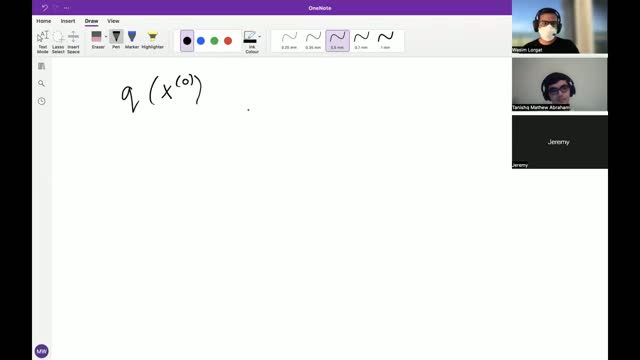

In [ ]:
fetch_frame(VIDEO_ID, PORT, 148)

Tanishq adds that it's helpful to think about \(x^0\) in a practical, concrete way: if we're working with images, then \(x^0\) represents the images. So \(x^0\) might be an MNIST digit.

Then we have \(q\). We can look at it as a box — a function that takes in \(x^0\) and gives us the probability that this \(x^0\) (an image) looks like an MNIST digit. In this case, you might get 0.98 — quite a high probability.

Jeremy jumps in: this looks a lot like the "magic API" from the start of lesson one, where you feed in a digit and it gives you back a probability. Waseem confirms: absolutely, it's a magic API. We don't know and couldn't write down what \(q\) is, but we imagine that somebody has it somewhere.

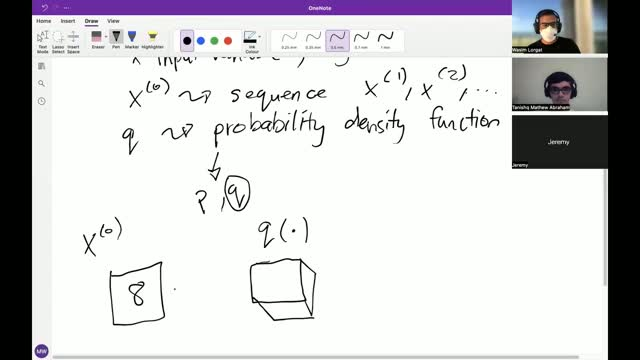

In [ ]:
fetch_frame(VIDEO_ID, PORT, 375)

If you modified the image, you might get a smaller number.

Another thing worth mentioning: probability density functions — these "magic APIs" that give us a number telling us how likely the thing is — you don't often see them and they very rarely appear in your code. But it turns out they are very useful tools to work with random quantities, because they allow you to represent random quantities as ordinary functions. And because they're functions, you have centuries' worth of math to analyze and understand them. So you'll often find PDFs in papers, and eventually they work out to really simple equations or formulas that end up in your code.

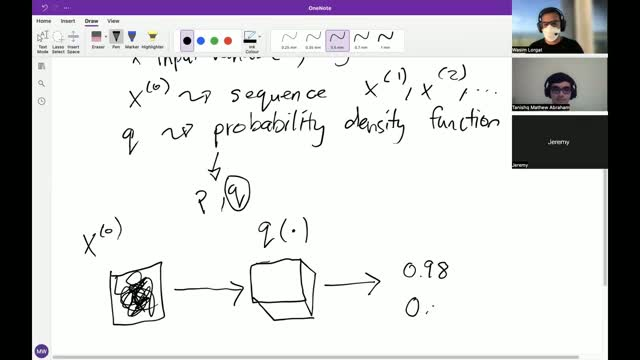

In [ ]:
fetch_frame(VIDEO_ID, PORT, 438)

## 3. Math Behind Lesson 9's "Magic API"

So we have \(q(x^0)\), and now we introduce another probability density function. As Tanishq said, this one is going to turn out to have a really nice simple form.

The next thing we define is \(q(x^t \mid x^{t-1})\). This is another probability density function, and the bar ("|") means it's a **conditional** probability density function. You can think of it as: you are given the thing on the right to calculate probabilities over the thing on the left. In this case, you can think of it as something that takes images (another magic API) and produces other images. We don't know what these look like yet because we haven't defined them.

This \(x^{t-1}\) could be \(x^0\), and then \(x^t\) would be \(x^1\).

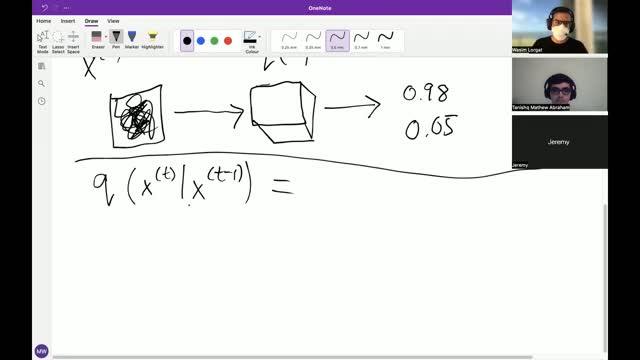

In [ ]:
fetch_frame(VIDEO_ID, PORT, 565)

Something worth noting: this notation can be confusing because we said \(q\) is one thing earlier, and now \(q\) seems to be another thing. Strictly speaking, you would define the first one and the second one with subscripts, and the notation we see is just a shortcut where they imply the meaning from what's inside the parentheses.

Tanishq clarifies: in the diffusion model literature, they use \(q\) and \(p\) to describe different processes of the diffusion model — \(q\) for one process, \(p\) for another. We'll see this as we go.

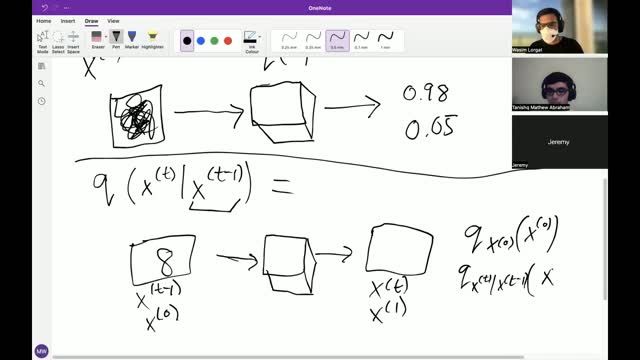

In [ ]:
fetch_frame(VIDEO_ID, PORT, 655)

Now let's describe what this \(q\) does to the image on the left to produce the one on the right. We define this forward transition as:

\[q(x^t \mid x^{t-1}) = \mathcal{N}(x^t;\; \sqrt{1 - \beta_t}\, x^{t-1},\; \beta_t \mathbf{I})\]

The semicolon groups things together: the thing on the left (\(x^t\)) is the variable that this is a probability distribution *for*, and the things on the right (\(\sqrt{1-\beta_t}\, x^{t-1}\) and \(\beta_t \mathbf{I}\)) are the **parameters** of the distribution — the mean and covariance.

So the bit after the semicolon is what we're used to seeing to describe a normal distribution: the **mean** and the **variance**. We're going to be sampling random numbers from that normal distribution according to that mean and variance.

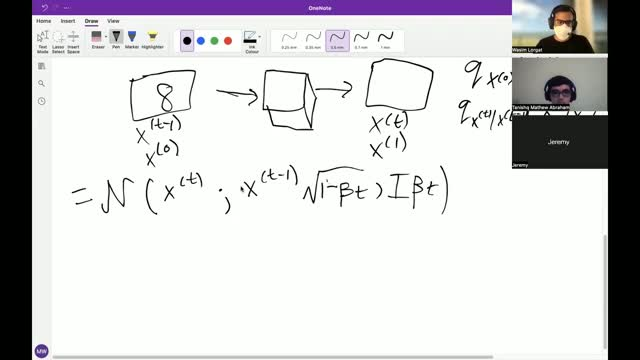

In [ ]:
fetch_frame(VIDEO_ID, PORT, 765)

The fancy \(\mathcal{N}\) stands for the **normal** (also known as **Gaussian**) distribution — probably the most well-known probability distribution you can find. When we say "well-known," we mean these things pop up everywhere. In all sorts of fields, measuring all sorts of things, it turns out they follow roughly something that looks like this distribution. Because they pop up so much, people have studied all of their properties and we understand them really well now.

The reasons they're used often in cases like this:
1. They are described by just **two parameters**: the mean (\(\mu\)) and the covariance (\(\Sigma\))
2. They have "thin tails" — you only need to describe their behavior in a small region of space; you can ignore the rest

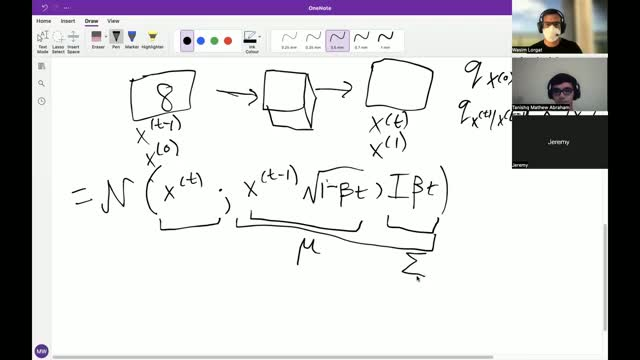

In [ ]:
fetch_frame(VIDEO_ID, PORT, 855)

Tanishq draws a quick example of a normal distribution. For a single one-dimensional random variable (just a single float), the distribution looks like the classic bell curve. The peak is at the mean (\(\mu\)), and the spread is described by the variance. For a single variable you'd use a lowercase \(\sigma\) (standard deviation); in our case we use a capital \(\Sigma\) because we're dealing with multiple variables / multiple dimensions.

Tanishq notes: typically lowercase \(\sigma\) represents the standard deviation, which is the square root of the variance. So \(\sigma^2\) is the variance. You may see papers write it as \(\sigma^2\) to make this explicit.

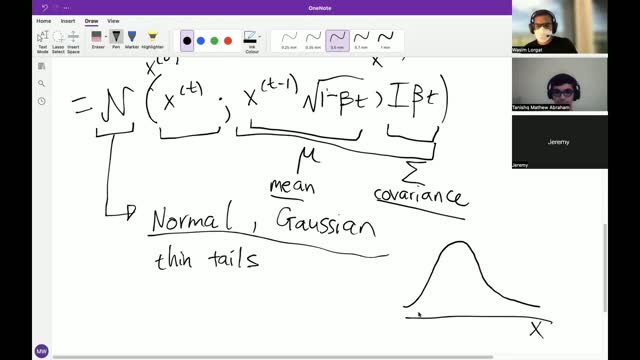

In [ ]:
fetch_frame(VIDEO_ID, PORT, 993)

## 4. CLIP (Contrastive Language–Image Pre-training)

Jeremy jumps in to explain the covariance matrix, connecting it to something that came up in a previous lesson about CLIP.

In the CLIP lesson, they had various pictures along one axis and various sentences along the other, and took the dot product of their embeddings — if the dot products are high, that means the items are similar to each other.

Now, if instead of images on one side, you had the **exact same vectors on each side**, then what you get is basically \((x - \bar{x})^2\) — and that is the **variance** for each of those vectors.

But the interesting thing is: you're not just doing one normal distribution. You've got a whole bunch of normal distributions — one for each pixel. One pixel might have a distribution centered here, another centered there. And it's more than that: it's possible that when one pixel tends to be higher, another pixel tends to be higher (or lower). This creates a surface in \(n\)-dimensional space where \(n\) is the number of pixels.

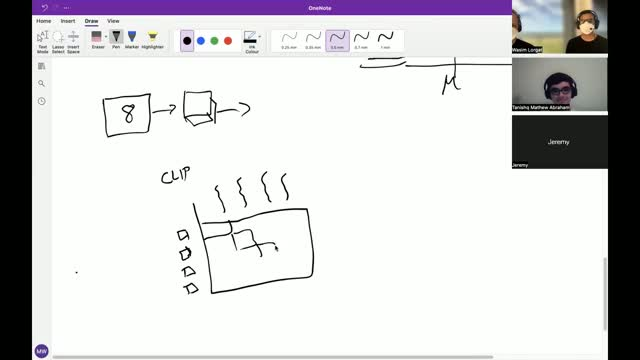

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1155)

If we multiply one vector by another (just like we did in CLIP) and the number is high, it says: when this pixel is high, that pixel tends to be high (and vice versa). If it's low, it says when this pixel is high, the other tends to be low.

But what happens if this value is **zero**? That says if this pixel is high, the other could be anything — there's no relationship between them. Statistically, we'd say these two pixels are **independent**.

If we set **all** the off-diagonal values to zero, that says every pixel is independent of every other pixel. Of course in real pictures that's not how pixels work, but that's the assumption we're making.

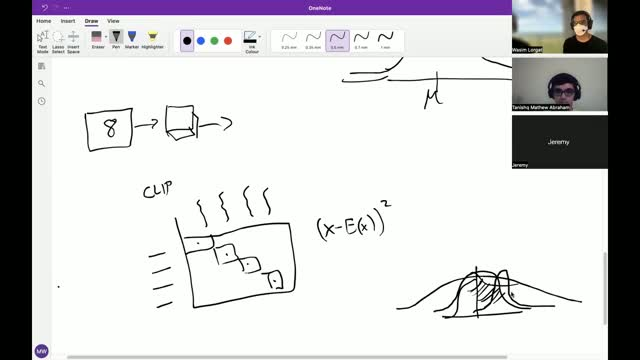

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1260)

We start with a very special matrix called \(\mathbf{I}\) (the **identity matrix**), which has ones on the diagonal and zeros everywhere else. If you multiply \(\mathbf{I}\) by a scalar \(\beta\), you get \(\beta\) on the diagonal and zeros elsewhere.

So \(\beta_t \mathbf{I}\) gives us a covariance matrix where each individual pixel has variance \(\beta_t\), and the covariance (relationship) between pixels is zero — they're expected to be independent.

That's where we're going from statistics you do in high school (variance is a single number) to statistics you do at university: covariance is now a **matrix**, not an individual number.

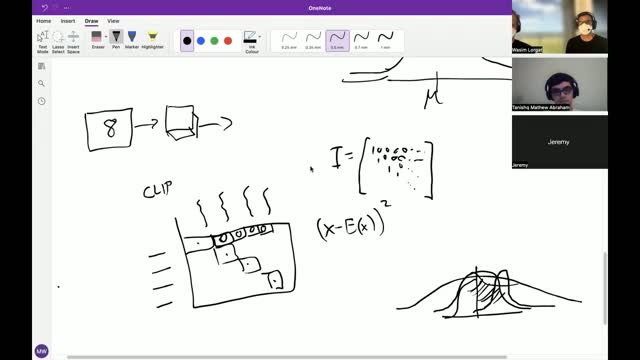

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1345)

Now let's look at how this behaves at the edges. It's really hard to just look at the formula and know what it means, so we typically try to describe it at the extremes.

**When \(\beta = 0\):**

\[\text{mean} = \sqrt{1 - 0} \cdot x^{t-1} = 1 \cdot x^{t-1} = x^{t-1}\]
\[\text{variance} = 0 \cdot \mathbf{I} = 0\]

A normal distribution with the mean of our previous image and variance of zero means **we get the same image back**. Tanishq clarifies: when you have variance of zero, there's really no noise — the distribution just says that's the only point you can get from it.

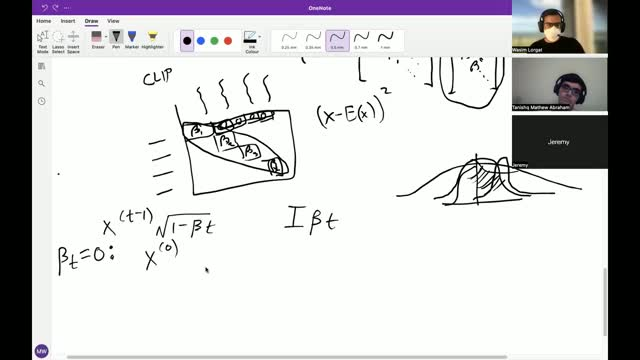

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1495)

**When \(\beta = 1\):**

\[\text{mean} = \sqrt{1 - 1} \cdot x^{t-1} = 0\]
\[\text{variance} = 1 \cdot \mathbf{I} = \mathbf{I}\]

If the variance is just \(\mathbf{I}\), then as Jeremy described, it implies a variance of 1 for each pixel. So our image through this function would just be **pure noise**: mean of zero, standard deviation of one.

Somewhere in between (\(0 < \beta < 1\)), we'd get some mixture — the lighter pixels of the digit plus some noise, maybe a bit darker.

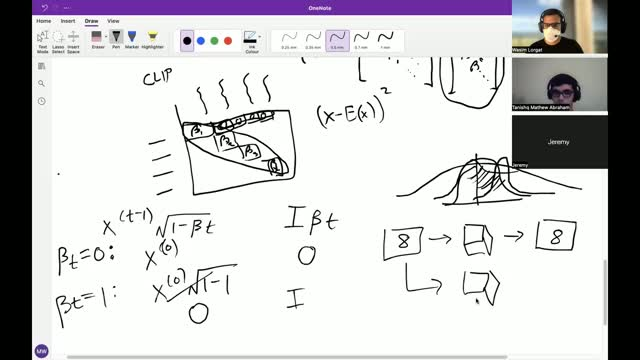

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1580)

## 5. Forward Diffusion (Markov Process with Gaussian Transitions)

We can draw the sequence of things that become progressively more noisy in very small steps, all the way until it becomes pure noise. This is what we call the **forward diffusion process**.

We can label these: the first one is a sample from our data distribution \(q(x^0)\). The transition to the next one is described by the conditional PDF \(q(x^1 \mid x^0)\), and so on.

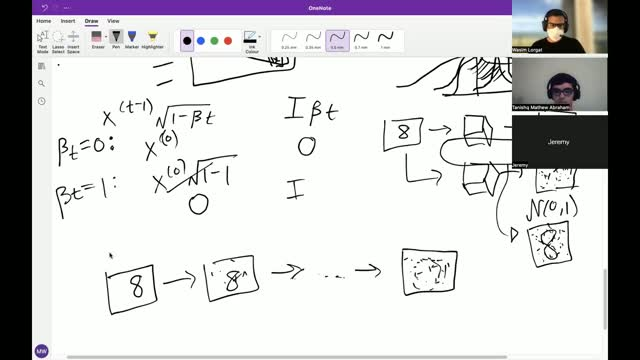

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1648)

The terminology mathematicians use to describe this is a **Markov process with Gaussian transitions**. This can sound quite scary, but we've just described exactly what it is:

- **Process**: something where there's a sequence involved
- **Markov**: the thing at time \(t\) depends **only** on the thing at \(t-1\)
- **Transition**: the function describing how you go from \(t-1\) to \(t\)
- **Gaussian**: the fact that the transition is a normal distribution

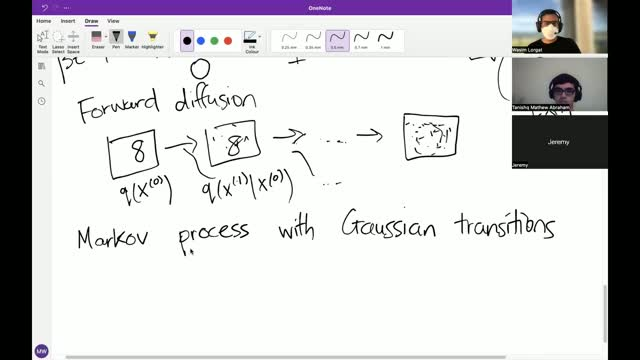

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1725)

Tanishq clarifies: when we say "sampling from the data distribution," that means trying to find some random data point that has a high likelihood according to that magic API. For some distributions like a Gaussian, if you know the parameters, it's very easy to do that sampling. In other cases it's quite difficult, and we have to figure out alternative ways. In the forward process, we just have these simple Gaussian transitions and we already know the parameters, so we can easily do the sampling.

One of the nice properties of Gaussian distributions: you can simply take some normal noise with mean zero and variance one (\(\mathcal{N}(0, 1)\)), multiply it by the standard deviation, and add the mean to get a sample at any desired mean and variance. That's how it happens under the hood when coding this up — most software libraries have a way of getting a sample from \(\mathcal{N}(0, 1)\), and then you just apply that equation.

This idea that we can't really sample from \(q(x^0)\) is exactly the problem that generative modeling is trying to solve: how do you represent this distribution in such a way that you can easily sample from it?

It turns out that if you have one of these processes with many, many steps — say a thousand very small steps going to the right, all eventually ending at noise — somebody, perhaps in the 1950s, discovered that you can represent the **process of going backwards** in exactly the **same functional form**, with just different parameters.

So if we say \(p\) is the thing that goes backwards — the previous step given the current one — then \(p\) has the same functional form: the transitions are also normal, but the mean is some unknown (represented as □) and the variance is some unknown (represented as △):

\[p(x^{t-1} \mid x^t) = \mathcal{N}(x^{t-1};\; \square,\; \triangle)\]

Tanishq confirms and adds: \(q\) describes the **forward** process, and \(p\) describes the **reverse** process. That's why the papers use \(q\) for one and \(p\) for the other. Waseem's analogy: \(p\) is like \(x\) — it's the one we want to figure out. \(q\) is like \(y\) — it's supplementary.

We have this functional form, and the next question is: how can we figure out what those unknown parameters are?

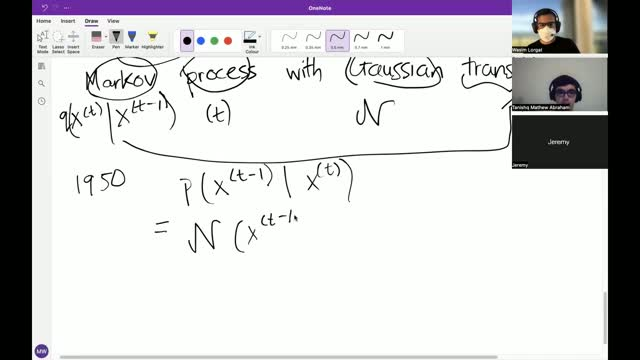

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2015)

## 6. Likelihood vs Log Likelihood

This goes back to early statistics literature: you can fit this model by maximizing what's called the **likelihood function**. You try different parameters until you have one that maximizes the likelihood.

It turns out we can't quite do this exactly, because you would need to calculate some integral over very high-dimensional continuous values — you can't actually calculate this. Tanishq explains: we're having thousands of steps in this reverse process, and for each step there are many possible values. It's hard to evaluate over all those thousands of steps and all possible values — that's where the challenge arises.

So you might see people talk not about the likelihood function, but about the **log likelihood**. The log is a computational trick with a few useful properties:

1. It's **monotonically increasing** — because it's always increasing, you get the same optimal parameters whether you optimize the log likelihood or the likelihood
2. It takes **products to sums** — this is helpful because joint distributions are products, and sums are easier to work with
3. The normal distribution has **exponential functions**, and those disappear with the log

So the log likelihood is a much friendlier thing to optimize.

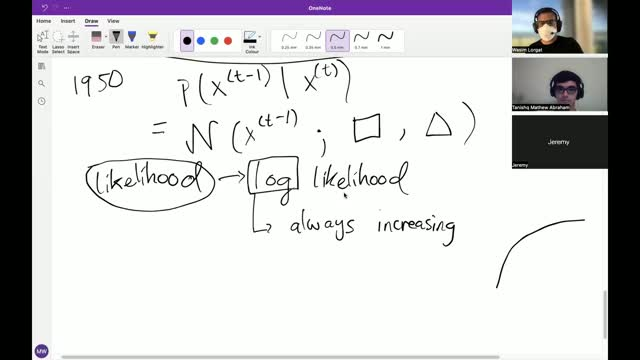

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2210)

There's one more step: we still can't optimize the log likelihood directly. But — and this is the beauty of math — somebody figured out a long time ago that there's a way to optimize some other quantity called the **ELBO** (Evidence Lower Bound).

- **Evidence** is just another name for the likelihood
- **Lower bound** means if you optimize this, it's almost as good as optimizing the thing we really want — and this one we **can** calculate very easily

So you can use the ELBO as a **loss function** to train neural networks that predict the unknown mean (□) and variance (△) of the reverse process.

Once you have those, you can start with pure noise, keep calling these neural networks, sampling from normal distributions, applying that iteratively over many steps, and you recover the data distribution.

One important clarification: you can recover the **whole distribution**, but you can't necessarily take a single image, convert it to pure noise, and then convert it back. This operates at the **distribution level** — you can reconstruct the whole magic API, and if you can do that, you can generate images: digits, cats, dogs, or whatever you want.

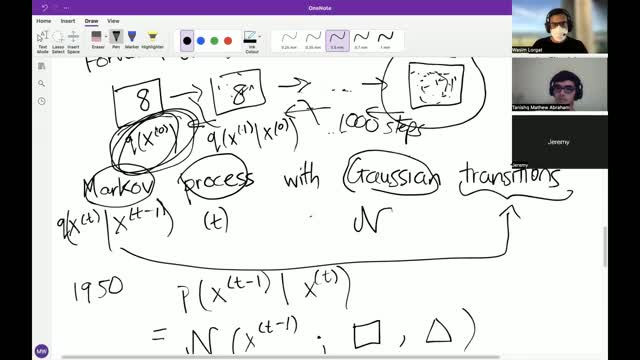

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2390)

Tanishq clarifies the ELBO loss function: what we're really doing is trying to **match** the distributions in the reverse process to those we see in the forward process. There's a specific function called **KL Divergence** that can compare probability distributions. Again, because we're dealing with Gaussians, you can calculate that analytically and the math becomes very simple. We want to minimize the difference between the distributions in the forward and reverse processes.

## 7. Denoising Diffusion Probabilistic Model (DDPM)

There's one more major step to get closer to the form you would have seen in Jeremy's lesson. The 2020 paper — DDPM, which stands for **Denoising Diffusion Probabilistic Model** — made two key simplifying assumptions:

1. The **variance** of the reverse process is just a constant — we don't learn it
2. The **step size** (the variance of the noise added at each forward step) is also a constant — we don't learn that either

So we're just predicting the **mean**, and these constants are set to really convenient values.

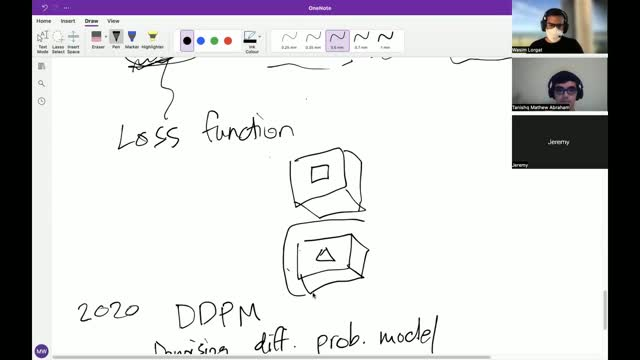

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2565)

Then the loss turns out to be: **predict the noise**. You can restructure the whole thing as: train a network that takes in images and tells you what part of the image is noise. Thanks to these simplifying assumptions — and even though they are simplifications — it turns out you can train models that produce much better images.

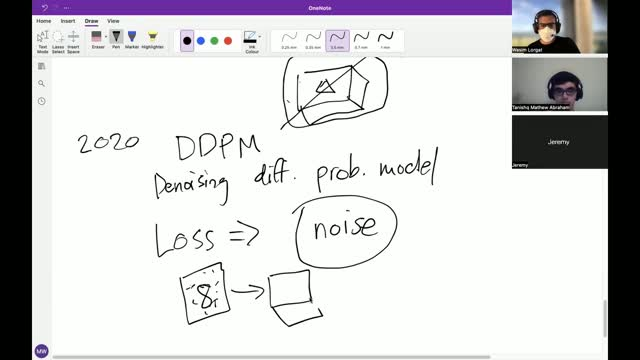

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2615)

Tanishq connects this to the **score function** perspective. In Jeremy's lesson, the idea is that we want to figure out the gradient of the likelihood function. If we had information about this gradient, we could use it to produce images with high likelihood.

The idea: we add noise to images we have (which decreases the likelihood), and we want to learn how to get back to high-likelihood images. This denoising process provides an estimate of the gradient.

There are theorems from the 1950s that demonstrate, especially in the case of Gaussian noise, this denoising process is equivalent to learning the **score function** — the gradient of the log likelihood:

\[\text{score function} = \nabla_x \log p(x)\]

So the noise-predicting approach from the probabilistic framework (DDPM) and the score-based perspective are **equivalent**: predicting the noise is the same as learning the score function. That's how these two bodies of literature connect with each other.

Waseem reflects: that's the beauty of the math side of things — you find relationships between different fields and even between different centuries, and that allows you to do really powerful and unexpected things.

## 8. Conclusion

**Quick recap:**

1. We started with our **data distribution** \(q(x^0)\), which we want to model
2. We defined the **forward diffusion process** — a way of adding noise in small Gaussian steps
3. Thanks to a discovery from the 1950s, the **reverse process** has the same functional form
4. We can train a neural network using the **ELBO** as a loss function
5. The 2020 DDPM paper showed that with simplifying assumptions, all we need to do is **predict the noise**, using the **MSE** (mean squared error) — a very simple framing
6. Tanishq explained the **score function** approach (gradient of log likelihood) — another way to derive all of this, connecting two different bodies of literature

Waseem encourages checking out the course lesson, notes there's no need to be intimidated if you don't understand the math, and recommends Jono's video as well for a deeper dive into the code and concepts. Jeremy clarifies: you don't need to understand all the math in this video — they'll be covering the math you need over many more hours in the lessons.

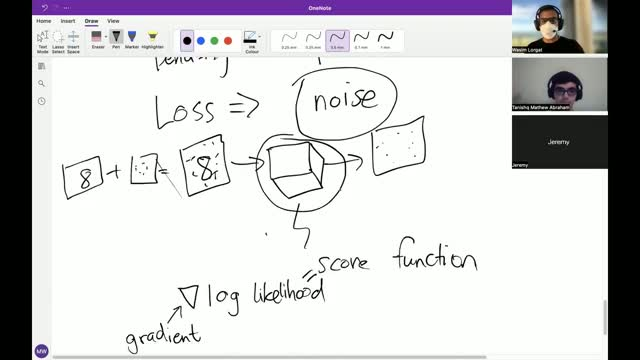

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2940)